# Hypothesis analysis

In [1]:
import pandas as pd

blocks_gdf = pd.read_pickle('./data/saint_petersburg/blocks.pickle')

In [2]:
blocks_gdf['land_use'] = blocks_gdf.apply(lambda s : s['land_use'] if s['share'] > 0 else None, axis=1)

## ANOVA

In [3]:
import pandas as pd
from scipy import stats
from blocksnet.enums import LandUse

def anova(column : str) -> tuple[float, float]:
    groups = []

    for land_use in LandUse:
        values = blocks_gdf[blocks_gdf.land_use == land_use][column].values
        groups.append(values)

    return stats.f_oneway(*groups)

def interpret_p_val(p_val : float) -> str:
    if p_val < 0.05:
        return 'Есть статистически значимые различия между группами'
    return 'Недостаточно доказательств, чтобы утверждать, что средние различаются'

data = []
for column in ['footprint_area', 'build_floor_area', 'living_area']:
    f_val, p_val = anova(column)
    data.append({
        'parameter': column,
        'f_val': f_val,
        'p_val': p_val,
        'desc': interpret_p_val(p_val)
    })
    
pd.DataFrame(data).set_index('parameter')

,f_val,p_val,desc
parameter,,,
footprint_area,254.672200,8.354609e-303,Есть статистически значимые различия между гру...
build_floor_area,116.695623,1.231977e-142,Есть статистически значимые различия между гру...
living_area,112.834582,5.624955e-138,Есть статистически значимые различия между гру...


**Вывод**: между группами (`land_use`) существуют статистически значимые различия

## Moran

In [4]:
import geopandas as gpd
import libpysal
from esda.moran import Moran

# Предположим, что у тебя есть GeoDataFrame gdf с колонкой 'land_use' и геометрией кварталов

# 1️⃣ Создаём матрицу весов соседства (Queen — соседство по общим границам)
w = libpysal.weights.Queen.from_dataframe(blocks_gdf, use_index=True)
w.transform = 'r'  # row-standardization

results = []
for param in ['footprint_area', 'build_floor_area', 'living_area']:
    moran = Moran(blocks_gdf[param], w)
    results.append({
        'parameter': param,
        "Moran_I": moran.I,
        "p_value": moran.p_sim
    })

/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 223 disconnected components.
 There are 182 islands with ids: 157, 380, 381, 510, 944, 1260, 1425, 1443, 1465, 1921, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 2599, 2630, 3307, 3308, 3309, 3310, 3311, 3314, 3328, 3329, 3332, 3333, 3334, 3335, 3359, 3360, 3363, 3364, 3365, 3366, 3367, 3368, 3369, 3370, 3378, 3379, 3380, 3396, 3397, 3400, 3401, 3407, 3410, 3411, 3449, 3450, 3453, 3454, 3455, 3461, 3483, 3553, 3814, 3826, 3827, 3934, 3945, 4088, 4089, 4090, 4091, 4092, 4093, 4094, 4095, 4096, 4097, 4098, 4099, 4100, 4101, 4102, 4103, 4104, 4105, 4106, 4107, 4108, 4109, 4110, 4111, 4112, 4163, 4241, 4327, 4328, 4359, 4365, 4366, 4385, 4386, 4387, 4388, 4576, 4577, 4578, 4850, 4851, 5028, 5029, 5030, 5031, 5049, 5050, 5122, 5123, 5124, 5125, 5126, 5127, 5128, 5129, 5158, 5159, 5160, 5183,

('WARNING: ', 157, ' is an island (no neighbors)')
('WARNING: ', 380, ' is an island (no neighbors)')
('WARNING: ', 381, ' is an island (no neighbors)')
('WARNING: ', 510, ' is an island (no neighbors)')
('WARNING: ', 944, ' is an island (no neighbors)')
('WARNING: ', 1260, ' is an island (no neighbors)')
('WARNING: ', 1425, ' is an island (no neighbors)')
('WARNING: ', 1443, ' is an island (no neighbors)')
('WARNING: ', 1465, ' is an island (no neighbors)')
('WARNING: ', 1921, ' is an island (no neighbors)')
('WARNING: ', 1963, ' is an island (no neighbors)')
('WARNING: ', 1964, ' is an island (no neighbors)')
('WARNING: ', 1965, ' is an island (no neighbors)')
('WARNING: ', 1966, ' is an island (no neighbors)')
('WARNING: ', 1967, ' is an island (no neighbors)')
('WARNING: ', 1968, ' is an island (no neighbors)')
('WARNING: ', 1969, ' is an island (no neighbors)')
('WARNING: ', 1970, ' is an island (no neighbors)')
('WARNING: ', 1971, ' is an island (no neighbors)')
('WARNING: ', 197

In [5]:
import pandas as pd
results_df = pd.DataFrame(results).set_index('parameter')
results_df

,Moran_I,p_value
parameter,,
footprint_area,0.250678,0.001
build_floor_area,0.337822,0.001
living_area,0.332009,0.001


Интерпретация:
- `Moran_I` -- положительная слабая-умеренная (`[0.1, 0.3]`, `[0.3, 0.5]`) автокорреляция , похожие значения сгруппированы (`High-High`, `Low-Low`)
- `p_value` -- статистически значимые различия, автокорреляция реальна, а не случайна (`< 0.05`) 

In [6]:
import matplotlib.pyplot as plt
from esda.moran import Moran_Local

parameters = ['footprint_area', 'build_floor_area', 'living_area']

gdf = blocks_gdf.copy()

# Матрица весов соседства (Queen)
w = libpysal.weights.Queen.from_dataframe(gdf, use_index=True)
w.transform = 'r'

for param in parameters:
    # Локальный индекс Морана
    moran_loc = Moran_Local(gdf[param], w)
    
    # Добавляем результаты в gdf
    gdf[f'{param}_moran'] = moran_loc.Is
    gdf[f'{param}_p'] = moran_loc.p_sim
    
    # Классификация по квадрантам
    cluster_labels = []
    for q, p_val in zip(moran_loc.q, moran_loc.p_sim):
        if p_val >= 0.05:
            cluster_labels.append("NS")  # not significant
        else:
            if q == 1:
                cluster_labels.append("HH")
            elif q == 2:
                cluster_labels.append("LH")
            elif q == 3:
                cluster_labels.append("HL")
            elif q == 4:
                cluster_labels.append("LL")
    gdf[f'{param}_cluster'] = cluster_labels

/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 223 disconnected components.
 There are 182 islands with ids: 157, 380, 381, 510, 944, 1260, 1425, 1443, 1465, 1921, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 2599, 2630, 3307, 3308, 3309, 3310, 3311, 3314, 3328, 3329, 3332, 3333, 3334, 3335, 3359, 3360, 3363, 3364, 3365, 3366, 3367, 3368, 3369, 3370, 3378, 3379, 3380, 3396, 3397, 3400, 3401, 3407, 3410, 3411, 3449, 3450, 3453, 3454, 3455, 3461, 3483, 3553, 3814, 3826, 3827, 3934, 3945, 4088, 4089, 4090, 4091, 4092, 4093, 4094, 4095, 4096, 4097, 4098, 4099, 4100, 4101, 4102, 4103, 4104, 4105, 4106, 4107, 4108, 4109, 4110, 4111, 4112, 4163, 4241, 4327, 4328, 4359, 4365, 4366, 4385, 4386, 4387, 4388, 4576, 4577, 4578, 4850, 4851, 5028, 5029, 5030, 5031, 5049, 5050, 5122, 5123, 5124, 5125, 5126, 5127, 5128, 5129, 5158, 5159, 5160, 5183,

('WARNING: ', 157, ' is an island (no neighbors)')
('WARNING: ', 380, ' is an island (no neighbors)')
('WARNING: ', 381, ' is an island (no neighbors)')
('WARNING: ', 510, ' is an island (no neighbors)')
('WARNING: ', 944, ' is an island (no neighbors)')
('WARNING: ', 1260, ' is an island (no neighbors)')
('WARNING: ', 1425, ' is an island (no neighbors)')
('WARNING: ', 1443, ' is an island (no neighbors)')
('WARNING: ', 1465, ' is an island (no neighbors)')
('WARNING: ', 1921, ' is an island (no neighbors)')
('WARNING: ', 1963, ' is an island (no neighbors)')
('WARNING: ', 1964, ' is an island (no neighbors)')
('WARNING: ', 1965, ' is an island (no neighbors)')
('WARNING: ', 1966, ' is an island (no neighbors)')
('WARNING: ', 1967, ' is an island (no neighbors)')
('WARNING: ', 1968, ' is an island (no neighbors)')
('WARNING: ', 1969, ' is an island (no neighbors)')
('WARNING: ', 1970, ' is an island (no neighbors)')
('WARNING: ', 1971, ' is an island (no neighbors)')
('WARNING: ', 197

/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim
/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/esda/moran.py:1350: RuntimeWarning: invalid value encountered in divide
  self.z_sim = (self.Is - self.EI_sim) / self.seI_sim


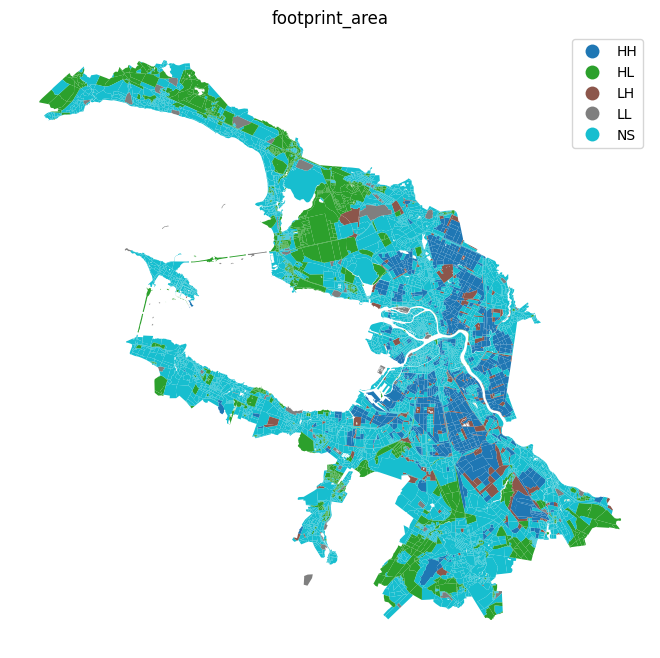

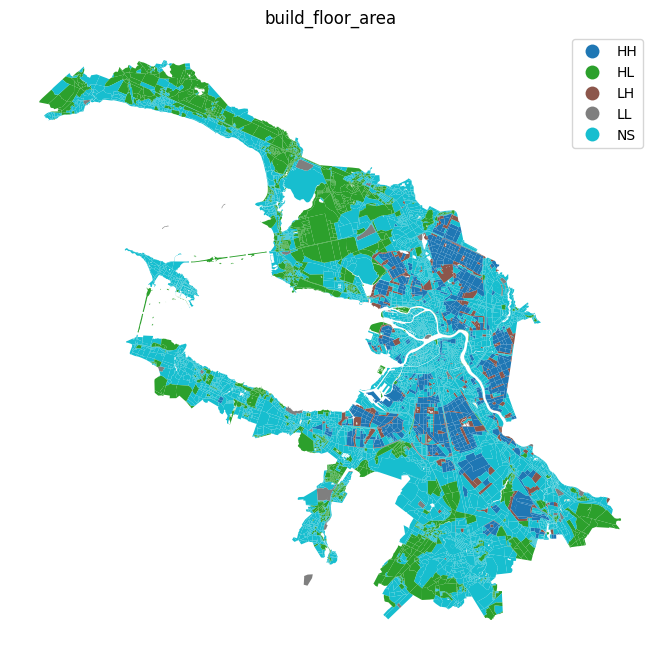

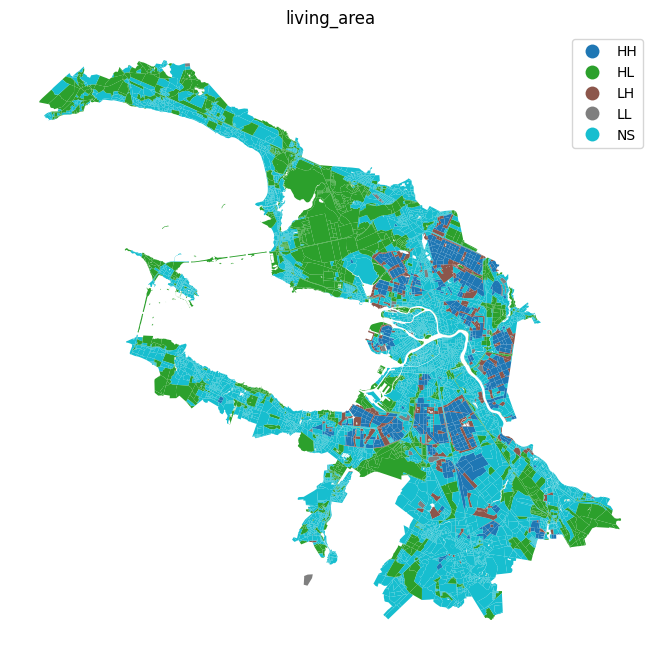

In [7]:
for column in ['footprint_area', 'build_floor_area', 'living_area']:
    ax = gdf.plot(f'{column}_cluster', figsize=(10,8), legend=True)
    ax.set_axis_off()
    ax.set_title(column)

## Site area correlation

In [8]:
import pandas as pd

# Выбираем колонки для анализа
params = ['site_area', 'footprint_area', 'build_floor_area', 'living_area']

# Считаем корреляционную матрицу (Пирсон)
corr_matrix = gdf[params].corr(method='pearson')
print(corr_matrix)

                  site_area  footprint_area  build_floor_area  living_area
site_area          1.000000        0.278336          0.193721     0.128083
footprint_area     0.278336        1.000000          0.741672     0.441422
build_floor_area   0.193721        0.741672          1.000000     0.886552
living_area        0.128083        0.441422          0.886552     1.000000


Параметры слабо зависят от `site_area` (площади застройки), но при этом хорошо коррелируют между собой.

## Baseline

In [9]:
from blocksnet.relations import generate_adjacency_graph

kemerovo_gdf = pd.read_pickle('./data/kemerovo/blocks.pickle')
graph = generate_adjacency_graph(kemerovo_gdf, 10)

2025-10-26 17:30:35.097 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_nodes:9 - Generating nodes
2025-10-26 17:30:35.099 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_edges:14 - Generating edges
2025-10-26 17:30:35.678 | SUCCESS  | blocksnet.relations.adjacency.core:generate_adjacency_graph:37 - Adjacency graph successfully generated: 1897 nodes, 6091 edges


In [10]:
blocks_ids = [i for i in graph.nodes if len(list(graph.neighbors(i)))>0]
kemerovo_gdf = kemerovo_gdf.loc[blocks_ids].copy()
graph = graph.subgraph(blocks_ids)

### Imputation

In [11]:
from blocksnet.preprocessing.imputing.development import DevelopmentImputer
from blocksnet.preprocessing.imputing.development._strategy import MultiScaleGNN, TorchGraphImputationStrategy

strategy = TorchGraphImputationStrategy(MultiScaleGNN)
strategy.load('model')
imputer = DevelopmentImputer(strategy)

In [ ]:
import math
import numpy as np
import pandas as pd
from tqdm import tqdm

def robust_r2(true_df, pred_df):
    residuals_sq = (true_df - pred_df)**2
    total_sq = (true_df - true_df.mean())**2
    return 1 - residuals_sq.median() / total_sq.median()

def log_r2(true_df, pred_df, eps=1e-3):
    log_true = np.log(true_df + eps)
    log_pred = np.log(pred_df + eps)
    return 1 - ((log_true - log_pred)**2).sum() / ((log_true - log_true.mean())**2).sum()

def metrics(sampling_rate : float):
    sampling_n = math.ceil(len(kemerovo_gdf) * sampling_rate)
    samples_df = kemerovo_gdf.sample(sampling_n)
    samples_ids = list(samples_df.index)
    pred_df = imputer.run(kemerovo_gdf, graph, samples_ids)
    pred_df = pred_df.loc[samples_ids]
    true_df = kemerovo_gdf.loc[samples_ids, pred_df.columns]
    
    diff = true_df - pred_df
    abs_df = diff.abs()
    
    mae = abs_df.mean()
    rmse = np.sqrt((diff**2).mean())
    r2 = 1 - (np.square(diff).sum() / np.square(true_df - true_df.mean()).sum())
    r2_robust_val = robust_r2(true_df, pred_df)
    r2_log_val = log_r2(true_df, pred_df)
    
    return mae, rmse, r2, r2_robust_val, r2_log_val

# словари для хранения результатов по признакам
results_mae = {'build_floor_area': [], 'footprint_area': [], 'living_area': []}
results_rmse = {'build_floor_area': [], 'footprint_area': [], 'living_area': []}
results_r2 = {'build_floor_area': [], 'footprint_area': [], 'living_area': []}
results_r2_robust = {'build_floor_area': [], 'footprint_area': [], 'living_area': []}
results_r2_log = {'build_floor_area': [], 'footprint_area': [], 'living_area': []}
sampling_rates = []

for i in range(9):
    sampling_rate = 0.1 * (i+1)
    sampling_rates.append(sampling_rate)
    
    maes_list = []
    rmses_list = []
    r2s_list = []
    r2_robust_list = []
    r2_log_list = []
    
    for _ in tqdm(range(100), desc=f"Sampling rate {sampling_rate}"):
        mae, rmse, r2, r2_robust_val, r2_log_val = metrics(sampling_rate)
        maes_list.append(mae)
        rmses_list.append(rmse)
        r2s_list.append(r2)
        r2_robust_list.append(r2_robust_val)
        r2_log_list.append(r2_log_val)
    
    # усредняем по маскам
    avg_mae = pd.concat(maes_list, axis=1).mean(axis=1)
    avg_rmse = pd.concat(rmses_list, axis=1).mean(axis=1)
    avg_r2 = pd.concat(r2s_list, axis=1).mean(axis=1)
    avg_r2_robust = pd.concat(r2_robust_list, axis=1).mean(axis=1)
    avg_r2_log = pd.concat(r2_log_list, axis=1).mean(axis=1)
    
    # сохраняем по признакам
    for col in ['build_floor_area', 'footprint_area', 'living_area']:
        results_mae[col].append(avg_mae[col])
        results_rmse[col].append(avg_rmse[col])
        results_r2[col].append(avg_r2[col])
        results_r2_robust[col].append(avg_r2_robust[col])
        results_r2_log[col].append(avg_r2_log[col])

# создаём DataFrame для каждого признака
df_mae = pd.DataFrame(results_mae, index=sampling_rates)
df_rmse = pd.DataFrame(results_rmse, index=sampling_rates)
df_r2 = pd.DataFrame(results_r2, index=sampling_rates)
df_r2_robust = pd.DataFrame(results_r2_robust, index=sampling_rates)
df_r2_log = pd.DataFrame(results_r2_log, index=sampling_rates)

df_mae.index.name = 'sampling_rate'
df_rmse.index.name = 'sampling_rate'
df_r2.index.name = 'sampling_rate'
df_r2_robust.index.name = 'sampling_rate'
df_r2_log.index.name = 'sampling_rate'


Sampling rate 0.1:   0%|          | 0/100 [00:00<?, ?it/s]/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
Sampling rate 0.1:   1%|          | 1/100 [00:00<00:21,  4.61it/s]/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
Sampling rate 0.1:   2%|▏         | 2/100 [00:00<00:16,  6.12it/s]/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)
Sampling rate 0.1:   3%|▎         | 3/100 [00:00<00:13,  7.01it/s]/home/vasilstar/masterplanning/.venv/lib/python3.10/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(sel

In [35]:
df_mae

,build_floor_area,footprint_area,living_area
sampling_rate,,,
0.1,13361.471355,6201.894765,8188.507617
0.2,13251.656544,6067.875018,8232.645459
0.3,13465.710167,6127.105438,8355.711142
0.4,13568.473734,6206.022307,8373.296272
0.5,13649.335270,6171.608480,8435.826949
0.6,13719.915064,6303.807131,8380.446969
0.7,13740.300469,6296.871481,8392.810460
0.8,13833.123198,6361.776768,8399.693265
0.9,13924.289050,6413.811085,8428.275511


In [36]:
df_rmse

,build_floor_area,footprint_area,living_area
sampling_rate,,,
0.1,42480.006173,16373.131719,29820.281545
0.2,42134.782070,15660.570997,30142.713317
0.3,43713.634367,15838.404251,31236.465643
0.4,44073.780099,16399.703628,31353.425198
0.5,44796.418527,16231.744345,31942.339375
0.6,44576.718248,16745.915451,31555.054865
0.7,44815.964292,16520.983260,31762.974554
0.8,44869.745204,16797.906328,31647.641796
0.9,45262.779770,16886.853212,31851.750189


In [34]:
df_r2_robust

,build_floor_area,footprint_area,living_area
sampling_rate,,,
0.1,0.971179,0.860421,0.953884
0.2,0.971834,0.856607,0.959681
0.3,0.972944,0.859263,0.963778
0.4,0.972911,0.860138,0.962797
0.5,0.972888,0.855560,0.964366
0.6,0.972887,0.860793,0.964440
0.7,0.972268,0.855359,0.964436
0.8,0.972129,0.854560,0.964563
0.9,0.971926,0.852652,0.965100
